# Aprendizaje Federado + Seguridad (notebook adicional)



## Contexto: seguridad en aprendizaje federado

El servidor **nunca ve los datos** de los clientes: solo recibe **parámetros**. Bueno para la privacidad, pero abre una puerta de seguridad: un cliente **malicioso** controla su entrenamiento local y puede enviar actualizaciones **envenenadas**.

**Ataque de envenenamiento (data poisoning).** El cliente altera sus etiquetas antes de entrenar. Aquí hacemos un **label flipping dirigido**: intercambiamos **3 ↔ 7** en el cliente 0. Al promediar (FedAvg), el modelo global "aprende" esa confusión y **cae la precisión en las clases atacadas** (3 y 7), mientras la precisión **global** baja de forma más sutil — por eso hay que mirar la métrica **por clase**.

Conecta con la **Sesión 7 (Seguridad, operación y gobernanza)**.

## Entrenamiento con y sin envenamiento

Entrena **dos veces** con FedAvg (escenario **cross-silo**: 3 clientes, uno comprometido): una **sin ataque** y otra **con el cliente 0 envenenado** (3 ↔ 7). Evalúa la precisión **global** y **por clase**, y guarda un gráfico comparativo. Corre en **segundos** (numpy puro).

In [ ]:
"""
Aprendizaje federado + ataque de envenenamiento de datos (MLOps II).

Entrena un clasificador con FedAvg sobre el dataset 'digits' repartido entre
varios clientes (escenario cross-silo: pocas organizaciones, mucho dato cada una),
una vez SIN ataque y otra CON un cliente malicioso que intercambia las etiquetas
3 <-> 7 (label flipping dirigido). Compara la precision global y por clase, y
visualiza un grafico. .

"""
import numpy as np
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ---- Hiperparametros ----
NUM_CLIENTS = 3     # cross-silo: pocas organizaciones (una sera la comprometida)
ROUNDS = 25         # rondas de comunicacion
LOCAL_EPOCHS = 15   # epocas locales por ronda
LR = 0.5
SEED = 0
rng = np.random.RandomState(SEED)

# ---- 1) Datos ----
X, y = load_digits(return_X_y=True)
X = StandardScaler().fit_transform(X)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)
N_FEAT, N_CLS = X.shape[1], 10

# ---- 2) Modelo softmax (W, b): son los arrays que FedAvg promedia ----
def init_modelo():
    return np.zeros((N_FEAT, N_CLS)), np.zeros(N_CLS)

def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    e = np.exp(Z); return e / e.sum(axis=1, keepdims=True)

def onehot(y):
    O = np.zeros((len(y), N_CLS)); O[np.arange(len(y)), y] = 1; return O

def paso_sgd(W, b, X, y, lr):
    P = softmax(X @ W + b)
    D = (P - onehot(y)) / len(y)
    return W - lr * (X.T @ D), b - lr * D.sum(axis=0)

def evaluar(W, b):
    pred = np.argmax(Xte @ W + b, axis=1)
    global_acc = (pred == yte).mean()
    por_clase = {c: (pred[yte == c] == c).mean() if (yte == c).sum() else 0.0
                 for c in range(N_CLS)}
    return global_acc, por_clase

# ---- 3) Reparto entre clientes (IID) ----
def particionar(K):
    idx = rng.permutation(len(Xtr))
    return [[Xtr[c].copy(), ytr[c].copy()] for c in np.array_split(idx, K)]

# ---- 4) Ataque: intercambio de etiquetas 3 <-> 7 en un cliente ----
def envenenar(cliente):
    Xc, yc = cliente
    yc = yc.copy()
    m3, m7 = (yc == 3), (yc == 7)
    yc[m3], yc[m7] = 7, 3   # swap real
    return [Xc, yc]

# ---- 5) FedAvg ----
def entrenar_local(W, b, Xc, yc):
    Wl, bl = W.copy(), b.copy()
    for _ in range(LOCAL_EPOCHS):
        Wl, bl = paso_sgd(Wl, bl, Xc, yc, LR)
    return Wl, bl, len(Xc)

def federado(clientes):
    W, b = init_modelo()
    historia = []
    for _ in range(ROUNDS):
        ups = [entrenar_local(W, b, Xc, yc) for Xc, yc in clientes]
        n = sum(nk for _, _, nk in ups)
        W = sum((nk / n) * Wk for Wk, _, nk in ups)   # promedio ponderado
        b = sum((nk / n) * bk for _, bk, nk in ups)
        historia.append(evaluar(W, b)[0])
    return W, b, historia

# ---- 6) Correr sin y con ataque ----
base = particionar(NUM_CLIENTS)

print("--- Entrenamiento SIN ataque ---")
Wc, bc, hist_clean = federado([c[:] for c in base])
acc_clean, pc_clean = evaluar(Wc, bc)
print(f"Precision global (sin ataque): {acc_clean:.3f}")

print("\n--- Entrenamiento CON ataque de envenenamiento (cliente 0: 3<->7) ---")
envenenado = [c[:] for c in base]
envenenado[0] = envenenar(envenenado[0])
Wp, bp, hist_poison = federado(envenenado)
acc_poison, pc_poison = evaluar(Wp, bp)
print(f"Precision global (con ataque): {acc_poison:.3f}")

print("\nPrecision por clase (sin -> con ataque):")
for c in range(N_CLS):
    marca = "   <- objetivo del ataque" if c in (3, 7) else ""
    print(f"  Clase {c}: {pc_clean[c]:.2f} -> {pc_poison[c]:.2f}{marca}")

--- Entrenamiento SIN ataque ---
Precision global (sin ataque): 0.971

--- Entrenamiento CON ataque de envenenamiento (cliente 0: 3<->7) ---
Precision global (con ataque): 0.947

Precision por clase (sin -> con ataque):
  Clase 0: 1.00 -> 1.00
  Clase 1: 0.98 -> 0.98
  Clase 2: 0.98 -> 0.98
  Clase 3: 0.98 -> 0.87   <- objetivo del ataque
  Clase 4: 0.96 -> 0.96
  Clase 5: 0.98 -> 0.96
  Clase 6: 0.98 -> 0.98
  Clase 7: 1.00 -> 0.89   <- objetivo del ataque
  Clase 8: 0.88 -> 0.91
  Clase 9: 0.98 -> 0.96


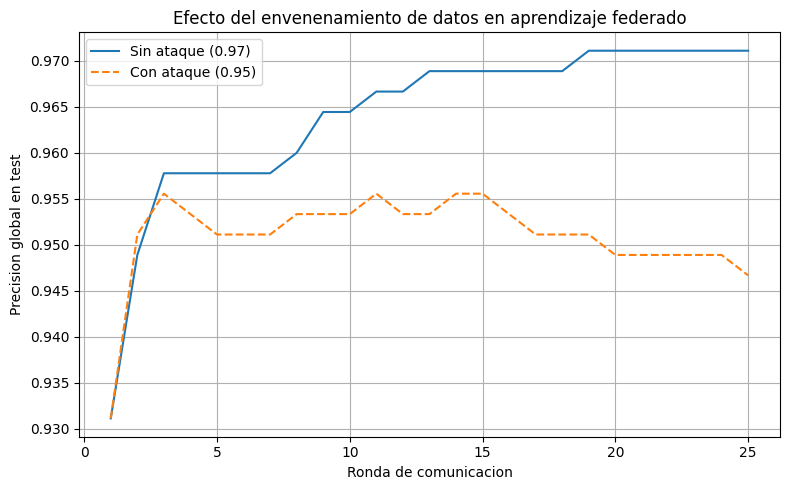

In [ ]:
# ---- 7) Grafico ----
plt.figure(figsize=(8, 5))
plt.plot(range(1, ROUNDS + 1), hist_clean,  label=f"Sin ataque ({acc_clean:.2f})")
plt.plot(range(1, ROUNDS + 1), hist_poison, "--", label=f"Con ataque ({acc_poison:.2f})")
plt.xlabel("Ronda de comunicacion")
plt.ylabel("Precision global en test")
plt.title("Efecto del envenenamiento de datos en aprendizaje federado")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()

## Qué observar en los resultados

Corrida de referencia (3 clientes, uno envenenado):

- **Global:** ~0.97 sin ataque → ~0.95 con ataque. La caída global es **moderada** y puede pasar desapercibida si solo miras esa métrica.
- **Por clase:** las clases **3 y 7 se desploman** (≈1.00 → ≈0.88), mientras el resto se mantiene ≈0.96–1.00. Ese patrón dirigido es la **firma del ataque**.

**Lección:** en producción, vigilar solo la métrica global no alcanza; el **monitoreo por clase / por segmento** es lo que delata un envenenamiento dirigido.

## Defensas (el plus de seguridad)

Cómo se mitiga — se profundiza en la **Sesión 7**:

- **Agregación robusta:** reemplazar el promedio de FedAvg por **mediana coordenada**, **trimmed mean** o **Krum**, que descartan actualizaciones atípicas.
- **Detección de anomalías:** medir la distancia de cada update al consenso y **filtrar** las que se desvían.
- **Acotar la contribución (clipping) + ruido (privacidad diferencial):** limitar cuánto puede mover un solo cliente al modelo global.
- **Validación / reputación de clientes:** evaluar cada update contra un set de validación limpio del servidor.
- **Monitoreo por clase/segmento con alertas:** detectar caídas dirigidas (como la de 3 y 7) apenas ocurren.

**Idea final:** federar mejora la privacidad, pero **no** la seguridad por sí solo. La confianza se construye con **agregación robusta + monitoreo + gobernanza**.

---


- **Mini-TP 5**: federar tu modelo y medir el trade-off privacidad vs performance.
- **Integrador**: si tu proyecto usa federado, esta demo de ataque/defensa es un gran diferencial para la capa de seguridad.